<a href="https://colab.research.google.com/github/OrastaRakhmatullayeva/ML-projects/blob/main/XG_Boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_curve
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [3]:
df=pd.read_csv("/content/online_shoppers_intention.csv")

In [4]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(125)

In [8]:
df=df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
(df['Revenue'].value_counts())/len(df['Revenue'])*100

,count
Revenue,
False,84.367063
True,15.632937


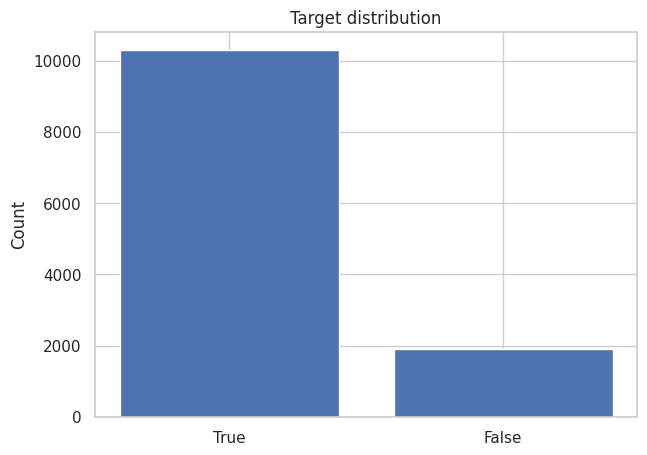

In [12]:
target_counts = df['Revenue'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["True", "False"], target_counts.values)
plt.title("Target distribution")
plt.ylabel("Count")
plt.show()

In [13]:
df["Weekend"] = df["Weekend"].astype(int)

df = pd.get_dummies(df, columns=["Month", "VisitorType"], drop_first=True)

In [18]:
X=df.drop(columns=['Revenue'])
y=df['Revenue']


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=RANDOM_STATE)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (9764, 26)
Test : (2441, 26)


In [20]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test, name="Model"):
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba)
    }

    return model, result, pred, proba

In [21]:

xgb_model = XGBClassifier(eval_metric="logloss", random_state=42)

model, result, pred, proba = evaluate_classifier(
    xgb_model, X_train, y_train, X_test, y_test, "XGBoost"
)

print(result)

{'Model': 'XGBoost', 'Accuracy': 0.8951249487914789, 'Precision': 0.6909090909090909, 'Recall': 0.5968586387434555, 'F1': 0.6404494382022472, 'ROC-AUC': np.float64(0.922526311506882)}


TRYING TO HYPERPARAMETS

In [22]:
param_grid = {
    "n_estimators": [50, 100, 300],
    "learning_rate": [0.01, 0.1, 0.3],
    "max_depth": [2, 4, 8]
}

results = []

for param_name, values in param_grid.items():
    for value in values:
        model = XGBClassifier(eval_metric="logloss", random_state=42, **{param_name: value})
        _, result, _, _ = evaluate_classifier(
            model, X_train, y_train, X_test, y_test, f"{param_name}={value}"
        )
        result["Parameter"] = param_name
        result["Value"] = value
        results.append(result)

results_df = pd.DataFrame(results)
print(results_df)

                Model  Accuracy  Precision    Recall        F1   ROC-AUC  \
0     n_estimators=50  0.891028   0.677914  0.578534  0.624294  0.925503   
1    n_estimators=100  0.895125   0.690909  0.596859  0.640449  0.922526   
2    n_estimators=300  0.892667   0.677515  0.599476  0.636111  0.918383   
3  learning_rate=0.01  0.895944   0.847826  0.408377  0.551237  0.934646   
4   learning_rate=0.1  0.898812   0.712934  0.591623  0.646638  0.932603   
5   learning_rate=0.3  0.895125   0.690909  0.596859  0.640449  0.922526   
6         max_depth=2  0.904547   0.727829  0.623037  0.671368  0.937850   
7         max_depth=4  0.897173   0.694362  0.612565  0.650904  0.928508   
8         max_depth=8  0.895125   0.685294  0.609948  0.645429  0.922200   

       Parameter   Value  
0   n_estimators   50.00  
1   n_estimators  100.00  
2   n_estimators  300.00  
3  learning_rate    0.01  
4  learning_rate    0.10  
5  learning_rate    0.30  
6      max_depth    2.00  
7      max_depth    4.0

In [23]:
for param_name in param_grid.keys():
    subset = results_df[results_df["Parameter"] == param_name]
    spread = subset["ROC-AUC"].max() - subset["ROC-AUC"].min()
    print(f"{param_name}: {spread:.4f}")


n_estimators: 0.0071
learning_rate: 0.0121
max_depth: 0.0157


max_depth (0.0157) > learning_rate (0.0121) > n_estimators (0.0071)

max_depth eng ko'p ta'sir qiladigan parameter

MIDDLE LEVEL

Rnadomized Search CV ni tanlaymiz chunki 20+ bo'lganligi sababli anchayin combination bo'lib ketadi

In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [50, 100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "max_depth": [2, 3, 4, 6, 8]
}

search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric="logloss", random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

best_model = search.best_estimator_

{'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.01}
0.9329549958946306


In [25]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

model_weighted = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=spw
)

_, result_weighted, _, _ = evaluate_classifier(
    model_weighted, X_train, y_train, X_test, y_test, "XGBoost + scale_pos_weight"
)

print(result_weighted)


comparison = pd.DataFrame([result, result_weighted])
print(comparison)

{'Model': 'XGBoost + scale_pos_weight', 'Accuracy': 0.8816058992216305, 'Precision': 0.6026490066225165, 'Recall': 0.7146596858638743, 'F1': 0.6538922155688622, 'ROC-AUC': np.float64(0.9227233776371898)}
                        Model  Accuracy  Precision    Recall        F1  \
0                 max_depth=8  0.895125   0.685294  0.609948  0.645429   
1  XGBoost + scale_pos_weight  0.881606   0.602649  0.714660  0.653892   

    ROC-AUC  Parameter  Value  
0  0.922200  max_depth    8.0  
1  0.922723        NaN    NaN  


PageValues     0.485644
Month_Nov      0.117707
Month_May      0.046840
Month_Mar      0.039232
BounceRates    0.038363
dtype: float32


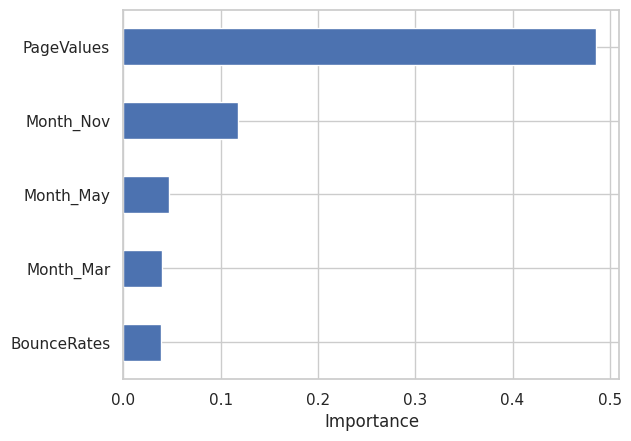

In [26]:
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
top5 = importances.sort_values(ascending=False).head(5)
print(top5)

top5.plot(kind="barh")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

PageValues (≈0.49)  --- eng dominant column for affecting the overall preformance

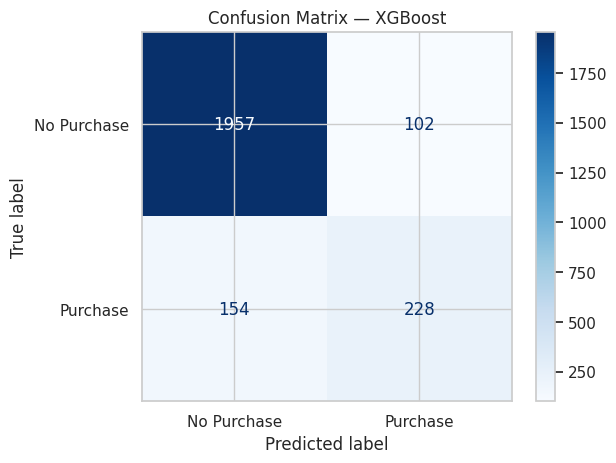

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Purchase", "Purchase"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — XGBoost")
plt.show()

In [28]:
final_comparison = pd.DataFrame([
    result,
    result_weighted
])
final_comparison = final_comparison[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
print(final_comparison.to_markdown(index=False))

| Model                      |   Accuracy |   Precision |   Recall |       F1 |   ROC-AUC |
|:---------------------------|-----------:|------------:|---------:|---------:|----------:|
| max_depth=8                |   0.895125 |    0.685294 | 0.609948 | 0.645429 |  0.9222   |
| XGBoost + scale_pos_weight |   0.881606 |    0.602649 | 0.71466  | 0.653892 |  0.922723 |
